In [ ]:
import os
import json
import numpy as np
from tqdm import tqdm
import torch
import cv2
from matplotlib import pyplot as plt

In [2]:
project_folder = '/mnt/new_ssd1/jiarui/boreas'
save_folder = '/mnt/new_ssd1/jiarui/boreas/LidarRadarGuide'

condition = 'snow'

if condition == 'snow':
    #sequence = 'boreas-2020-12-18-13-44'
    sequence = 'boreas-2021-01-26-11-22'
    first_frame = 1090
    last_frame = 1182
elif condition == 'sunshine':
    sequence = 'boreas-2020-12-18-13-44'
    first_frame = 3412
    last_frame = 3512
elif condition == 'rain':
    sequence = 'boreas-2021-04-29-15-55'
    first_frame = 890
    last_frame = 950
elif condition == 'static':
    sequence = 'boreas-2020-12-18-13-44'
    first_frame = 557
    last_frame = 633
else:
    print('Not valid')

dim = 2

data_json_name = f'{sequence}_{int(first_frame)}_{int(last_frame)}_{dim}d.json'
data_json_path = os.path.join(project_folder,'LidarRadarGuide', data_json_name)

# run python get_3d_radar_poses.py --project folder xx --sequence xx
# to get radar_poses.npy and radar_times.npy

poses = np.load(os.path.join(project_folder, sequence,'LidarRadarGuide', f'radar_poses_{dim}.npy'))
timestamps = np.load(os.path.join(project_folder, sequence,'LidarRadarGuide', 'radar_times.npy'))
# take radar as reference as radar's time resolution is less then lidar's (\delta_t_radar > \delta_t_lidar)

In [3]:
def LiDAR_2_Pano(
    local_points_with_intensities, lidar_H, lidar_W, intrinsics, max_depth=80.0
):
    pano, intensities = lidar_to_pano_with_intensities(
        local_points_with_intensities=local_points_with_intensities,
        lidar_H=lidar_H,
        lidar_W=lidar_W,
        lidar_K=intrinsics,
        max_depth=max_depth,
    )
    range_view = np.zeros((lidar_H, lidar_W, 3))
    range_view[:, :, 1] = intensities
    range_view[:, :, 2] = pano
    return range_view

def lidar_to_pano_with_intensities(
    local_points_with_intensities: np.ndarray,
    lidar_H: int,
    lidar_W: int,
    lidar_K: int,
    max_depth=80,
):
    """
    Convert lidar frame to pano frame with intensities.
    Lidar points are in local coordinates.

    Args:
        local_points: (N, 4), float32, in lidar frame, with intensities.
        lidar_H: pano height.
        lidar_W: pano width.
        lidar_K: lidar intrinsics.
        max_depth: max depth in meters.

    Return:
        pano: (H, W), float32.
        intensities: (H, W), float32.
    """
    # Un pack.
    local_points = local_points_with_intensities[:, :3]
    local_point_intensities = local_points_with_intensities[:, 3]
    fov_up, fov = lidar_K
    fov_down = fov - fov_up

    # Compute dists to lidar center.
    dists = np.linalg.norm(local_points, axis=1)

    # Fill pano and intensities.
    pano = np.zeros((lidar_H, lidar_W))
    intensities = np.zeros((lidar_H, lidar_W))
    for local_points, dist, local_point_intensity in zip(
        local_points,
        dists,
        local_point_intensities,
    ):
        # Check max depth.
        if dist >= max_depth:
            continue

        x, y, z = local_points
        beta = np.pi - np.arctan2(y, x)
        alpha = np.arctan2(z, np.sqrt(x**2 + y**2)) + fov_down / 180 * np.pi
        c = int(round(beta / (2 * np.pi / lidar_W)))
        r = int(round(lidar_H - alpha / (fov / 180 * np.pi / lidar_H)))

        # Check out-of-bounds.
        if r >= lidar_H or r < 0 or c >= lidar_W or c < 0:
            continue

        # Set to min dist if not set.
        if pano[r, c] == 0.0:
            pano[r, c] = dist
            intensities[r, c] = local_point_intensity
        elif pano[r, c] > dist:
            pano[r, c] = dist
            intensities[r, c] = local_point_intensity

    return pano, intensities

def cal_centerpose_bound_scale(
    lidar_rangeview_paths, lidar2worlds, fov_lidar, bound=1.0
):
    near = 200
    far = 0
    points_world_list = []
    for i, lidar_rangeview_path in enumerate(lidar_rangeview_paths):
        print(lidar_rangeview_path)
        pano = np.load(lidar_rangeview_path)
        point_cloud = pano_to_lidar(pano=pano[:, :, 2], lidar_K=fov_lidar)
        point_cloud = np.concatenate(
            [point_cloud, np.ones(point_cloud.shape[0]).reshape(-1, 1)], -1
        )
        dis = np.sqrt(
            point_cloud[:, 0] ** 2 + point_cloud[:, 1] ** 2 + point_cloud[:, 2] ** 2
        )
        near = min(min(dis), near)
        far = max(far, max(dis))
        points_world = (point_cloud @ lidar2worlds[i].T)[:, :3]
        points_world_list.append(points_world)
    print("near, far:", near, far)

    pc_all_w = np.concatenate(points_world_list)[:, :3]

    centerpose = [
        (np.max(pc_all_w[:, 0]) + np.min(pc_all_w[:, 0])) / 2.0,
        (np.max(pc_all_w[:, 1]) + np.min(pc_all_w[:, 1])) / 2.0,
        (np.max(pc_all_w[:, 2]) + np.min(pc_all_w[:, 2])) / 2.0,
    ]
    print("centerpose: ", centerpose)
    pc_all_w_centered = pc_all_w - centerpose

    bound_ori = [
        np.max(pc_all_w_centered[:, 0]),
        np.max(pc_all_w_centered[:, 1]),
        np.max(pc_all_w_centered[:, 2]),
    ]
    scale = bound / np.max(bound_ori)
    print("scale: ", scale)
    
    return scale, centerpose

def pano_to_lidar(pano, lidar_K):
    """
    Args:
        pano: (H, W), float32.
        lidar_K: lidar intrinsics (fov_up, fov)

    Return:
        local_points: (N, 3), float32, in lidar frame.
    """
    local_points_with_intensities = pano_to_lidar_with_intensities(
        pano=pano,
        intensities=np.zeros_like(pano),
        lidar_K=lidar_K,
    )
    return local_points_with_intensities[:, :3]

def pano_to_lidar_with_intensities(pano: np.ndarray, intensities, lidar_K):
    """
    Args:
        pano: (H, W), float32.
        intensities: (H, W), float32.
        lidar_K: lidar intrinsics (fov_up, fov)

    Return:
        local_points_with_intensities: (N, 4), float32, in lidar frame.
    """
    fov_up, fov = lidar_K

    H, W = pano.shape
    i, j = np.meshgrid(
        np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32), indexing="xy"
    )
    beta = -(i - W / 2) / W * 2 * np.pi
    alpha = (fov_up - j / H * fov) / 180 * np.pi
    dirs = np.stack(
        [
            np.cos(alpha) * np.cos(beta),
            np.cos(alpha) * np.sin(beta),
            np.sin(alpha),
        ],
        -1,
    )
    local_points = dirs * pano.reshape(H, W, 1)

    # local_points: (H, W, 3)
    # intensities : (H, W)
    # local_points_with_intensities: (H, W, 4)
    local_points_with_intensities = np.concatenate(
        [local_points, intensities.reshape(H, W, 1)], axis=2
    )

    # Filter empty points.
    idx = np.where(pano != 0.0)
    local_points_with_intensities = local_points_with_intensities[idx]

    return local_points_with_intensities



In [4]:
# Segment the sequence
#lidar_timestamps = read_lidar_csv(project_folder, sequence)
lidar_poses = np.load(os.path.join(project_folder, sequence,'LidarRadarGuide', f'lidar_poses_{dim}.npy'))
lidar_timestamps = np.load(os.path.join(project_folder, sequence,'LidarRadarGuide', 'lidar_times.npy'))
camera_poses = np.load(os.path.join(project_folder, sequence,'LidarRadarGuide', f'camera_poses_{dim}.npy'))
camera_timestamps = np.load(os.path.join(project_folder, sequence,'LidarRadarGuide', 'camera_times.npy'))
transform_json = {'frames': []}
file_id = 0

for i in tqdm(range(len(poses)), desc="Processing frames"):
    if i > first_frame and i <= last_frame:
        radar_time = timestamps[i]

        lidar_timestamps_diff = np.abs(lidar_timestamps - radar_time)
        closest_index = np.argmin(lidar_timestamps_diff)
        closest_timestamp = lidar_timestamps[closest_index]
        closest_lidarpose = lidar_poses[closest_index]
        # check if the closest timestamp file exists
        closest_file = os.path.join(project_folder,sequence,'lidar', f'{closest_timestamp}.bin')
        if not os.path.exists(closest_file):
            print(f"File {closest_file} does not exist. Skipping.")
            continue

        # camera
        camera_timestamps_diff = np.abs(camera_timestamps - radar_time)
        closest_index = np.argmin(camera_timestamps_diff)
        closest_timestamp = camera_timestamps[closest_index]
        closest_camera_pose = camera_poses[closest_index]
        closest_file_camera = os.path.join(project_folder,sequence,'camera', f'{closest_timestamp}.png')
        if not os.path.exists(closest_file_camera):
            print(f"File {closest_file_camera} does not exist. Skipping.")
            continue



        radar_pose = poses[i]

        radar_file = os.path.join(project_folder, sequence, 'radar', f'{radar_time}.png')
        if not os.path.exists(radar_file):
            print(f"File {radar_file} does not exist. Skipping.")
            AssertionError(f"File {radar_file} does not exist.")

        transform_json['frames'].append({
            'radar_timestamp': int(radar_time),
            'id': file_id,
            'radar_path': radar_file,
            'radar_pose': radar_pose.tolist(),
            'lidar_path':closest_file,
            'lidar_pose': closest_lidarpose.tolist(),
            'camera_path': closest_file_camera,
            'camera_pose': closest_camera_pose.tolist()
        })
        file_id = file_id + 1
    if i > last_frame:
        break

# Save the transform_json to a file
with open(data_json_path, 'w') as f:
    json.dump(transform_json, f, indent=4)
print(f"Transform JSON saved to {data_json_path}")

Processing frames:  21%|██        | 1183/5652 [00:00<00:00, 13052.76it/s]

Transform JSON saved to /mnt/new_ssd1/jiarui/boreas/LidarRadarGuide/boreas-2021-01-26-11-22_1090_1182_2d.json


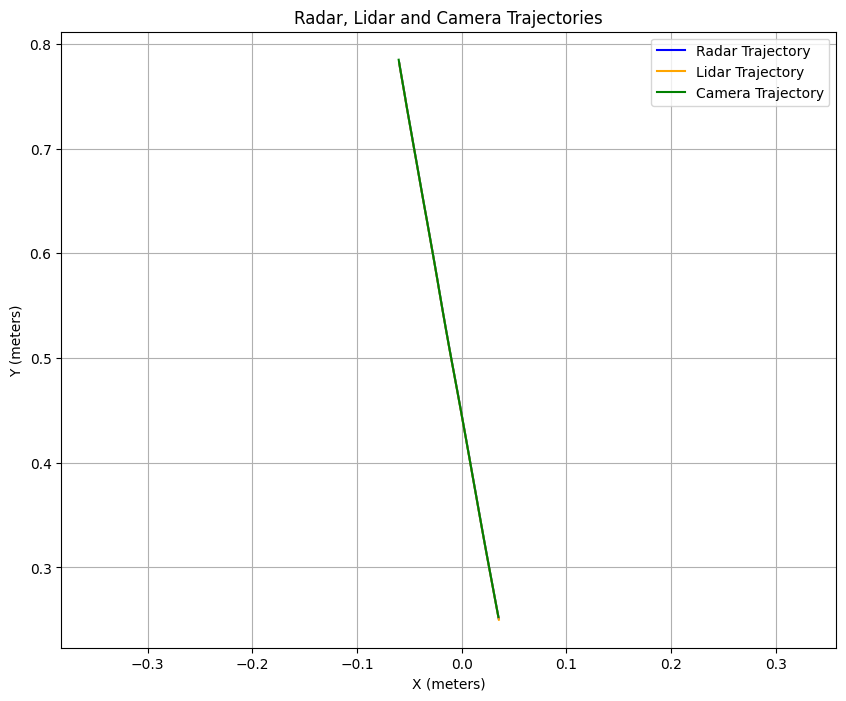

In [5]:
# Visualize radar and lidar trajectories
with open(data_json_path, 'r') as f:
    transform_data = json.load(f)

scale=0.0054003121549536775
offset=[-327.96177174337157, 547.3990811193262, 8.507940889512952]

radar_positions = []
lidar_positions = []
camera_positions = []
for frame in transform_data['frames']:
    radar_matrix = np.array(frame['radar_pose'])
    radar_positions.append(radar_matrix[:3, 3])
    lidar_matrix = np.array(frame['lidar_pose'])
    lidar_positions.append(lidar_matrix[:3, 3])
    camera_matrix = np.array(frame['camera_pose'])
    camera_positions.append(camera_matrix[:3, 3])

radar_positions = np.stack(radar_positions,axis=0)
radar_positions[:, :3] = (radar_positions[:, :3] - offset) * scale
lidar_positions = np.stack(lidar_positions,axis=0)
lidar_positions[:, :3] = (lidar_positions[:, :3] - offset) * scale
camera_positions = np.stack(camera_positions,axis=0)
camera_positions[:, :3] = (camera_positions[:, :3] - offset) * scale

radar_positions = np.array(radar_positions)
lidar_positions = np.array(lidar_positions)
camera_positions = np.array(camera_positions)
plt.figure(figsize=(10, 8))
plt.plot(radar_positions[:, 0], radar_positions[:, 1], label='Radar Trajectory', color='blue')
plt.plot(lidar_positions[:, 0], lidar_positions[:, 1], label='Lidar Trajectory', color='orange')
plt.plot(camera_positions[:, 0], camera_positions[:, 1], label='Camera Trajectory', color='green')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.title('Radar, Lidar and Camera Trajectories')
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()  

## LiDAR4D

In [7]:
# Generate lidar range views
H = 128 # number of vertical beams
W = int(360/0.2)

intrinsics = (15,40) # fov_up, fov_down
lidar_paths = [frame['lidar_path'] for frame in transform_data['frames']]

out_dir = os.path.join(project_folder, sequence,'lidar_range_view')
os.makedirs(out_dir, exist_ok=True) 

# for lidar_path in tqdm(lidar_paths, desc="Generating range views"):
#     point_cloud = np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 6)
#     points = point_cloud[:, :4]
#     pano = LiDAR_2_Pano(points, H, W, intrinsics,max_depth=300.0)
#     frame_pth = lidar_path.replace('lidar', 'lidar_range_view').replace('.bin', '.npy')
#     # check if the file exists
#     # if os.path.exists(frame_pth):
#     #     print(f"File {frame_pth} already exists. Skipping.")
#     #     continue
#     np.save(frame_pth, pano)

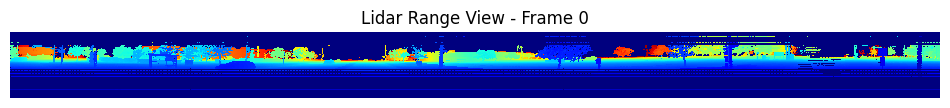

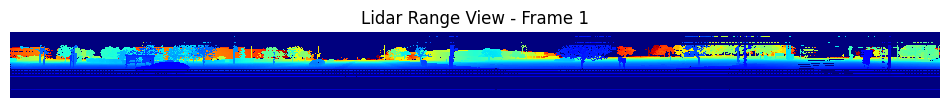

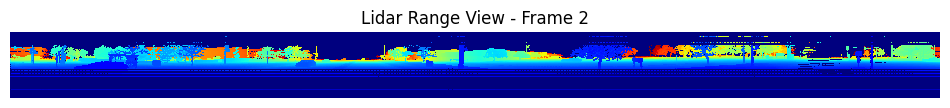

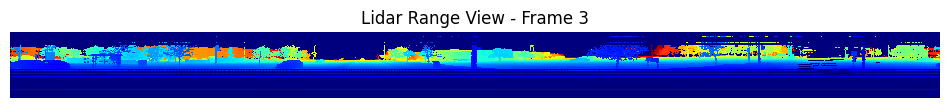

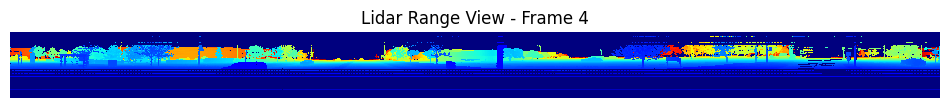

In [33]:
# Visualize the generated range view
# take the first 5 frames as examples
# range_view[:, :, 0] is the depth channel
# range_view[:, :, 1] is the intensity channel
for i in range(5):
    frame_pth = lidar_paths[i].replace('lidar', 'lidar_range_view').replace('.bin', '.npy')
    range_view = np.load(frame_pth)
    plt.figure(figsize=(12, 6))

    plt.imshow(range_view[:, :, 2], cmap='jet', interpolation='nearest') # 1 is intensity, 2 is depth
    plt.title(f'Lidar Range View - Frame {i}')
    plt.axis('off')
    plt.show()

In [8]:
# Generate LiDAR4D json
# split into train, val and test, val=test

# only select 4 frames uniformly as validation and test set
# e.g. [0-50], select [10,20,30,40] as val and test set
# the rest as training set
len_frames = len(transform_data['frames'])
i_val = np.linspace(0, len_frames-1, 6).astype(int).tolist()
i_val = i_val[1:-1]  # remove the first and last frame from val set

i_train = [i for i in range(len_frames) if i not in i_val]  
i_test = i_val

split_to_all_indices = {
    'train': i_train,
    'val': i_val,
    'test': i_test
}

for split, indices in split_to_all_indices.items():
    print(f"Processing split: {split} with {len(indices)} frames")
    id_split = [transform_data['frames'][i]['id'] for i in indices]
    lidar_paths_split = [transform_data['frames'][i]['lidar_path'].replace('lidar', 'lidar_range_view').replace('.bin', '.npy') for i in indices]
    lidar2world_split = [transform_data['frames'][i]['lidar_pose'] for i in indices]
    radar2world_split = [transform_data['frames'][i]['radar_pose'] for i in indices]
    radar_paths_split = [transform_data['frames'][i]['radar_path'] for i in indices]


    json_dict = {
        'w_lidar':W,
        'h_lidar':H,
        'num_frames':len_frames,
        'num_frames_split':len(indices),
        'frames':[
            {
            'frame_id':id,
            'lidar_file_path':lidar_path,
            'lidar2world': lidar2world,
            'radar_file_path': radar_path,
            'radar2world': radar2world,
            }
        for (
            id,
            lidar_path,
            lidar2world,
            radar_path,
            radar2world
        ) in zip(
            id_split,
            lidar_paths_split,
            lidar2world_split,
            radar_paths_split,
            radar2world_split
        )
        ],
    }

    Lidar4D_json_path = os.path.join(save_folder, f'Lidar4D_{sequence}_{split}_{first_frame}_{last_frame}_{dim}d.json')
    with open(Lidar4D_json_path, 'w') as f:
        json.dump(json_dict, f, indent=4)
    print(f"Lidar4D JSON saved to {Lidar4D_json_path}")

Processing split: train with 88 frames
Lidar4D JSON saved to /mnt/new_ssd1/jiarui/boreas/LidarRadarGuide/Lidar4D_boreas-2021-01-26-11-22_train_1090_1182_2d.json
Processing split: val with 4 frames
Lidar4D JSON saved to /mnt/new_ssd1/jiarui/boreas/LidarRadarGuide/Lidar4D_boreas-2021-01-26-11-22_val_1090_1182_2d.json
Processing split: test with 4 frames
Lidar4D JSON saved to /mnt/new_ssd1/jiarui/boreas/LidarRadarGuide/Lidar4D_boreas-2021-01-26-11-22_test_1090_1182_2d.json


In [9]:
## Calculate LiDAR4D config
with open(Lidar4D_json_path, 'r') as f:
    transform = json.load(f)
num_frames = transform["num_frames"]
frames = transform["frames"]
poses_lidar = []
paths_lidar = []
for f in tqdm(frames, desc=f"Loading {type} data"):
    pose_lidar = np.array(f["lidar2world"], dtype=np.float32)  # [4, 4]
    f_lidar_path = f["lidar_file_path"]
    poses_lidar.append(pose_lidar)
    paths_lidar.append(f_lidar_path)


fov_lidar = [float(x) for x in intrinsics]  # [fov_up, fov_down]
scale, centerpose = cal_centerpose_bound_scale(paths_lidar, poses_lidar, fov_lidar, bound=1.0)
config_path = os.path.join('/home/user/JR_workspace/LidarRadarGuide/LiDAR4D/configs', f'Lidar4D_{sequence}_{first_frame}_{last_frame}_{dim}d_config.txt')
with open(config_path, 'w') as f:
    f.write(f"path={save_folder}\n")
    f.write(f"sequence_id='{sequence}'\n")
    f.write(f"first_frame={first_frame}\n")
    f.write(f"last_frame={last_frame}\n")
    f.write(f"num_frames={num_frames}\n")
    f.write(f"scale={scale}\n")
    f.write(f"offset={centerpose}\n")
    f.write(f"fov_lidar={fov_lidar}\n")

radar_config_path = os.path.join('/home/user/JR_workspace/LidarRadarGuide/RF4D_flow/configs', f'Radar4D_{sequence}_{first_frame}_{last_frame}_{dim}d_config.txt')
with open(radar_config_path, 'w') as f:
    f.write(f"sequence_id='{sequence}'\n")
    f.write(f"first_frame={first_frame}\n")
    f.write(f"last_frame={last_frame}\n")
    f.write(f"num_frames={num_frames}\n")
    f.write(f"scale={scale}\n")
    f.write(f"offset={centerpose}\n")
    f.write('intrinsics_radar = {"opening_h": 0.9,"opening_v": 0.9,"num_range_bins": 3768,"bin_size_radar": 0.0596,"num_azimuths_radar": 400}\n')
    f.write('min_range_bin=50\n')


Loading <class 'type'> data: 100%|██████████| 4/4 [00:00<00:00, 63791.70it/s]


/mnt/new_ssd1/jiarui/boreas/boreas-2021-01-26-11-22/lidar_range_view/1611678415768067.npy
/mnt/new_ssd1/jiarui/boreas/boreas-2021-01-26-11-22/lidar_range_view/1611678420227295.npy
/mnt/new_ssd1/jiarui/boreas/boreas-2021-01-26-11-22/lidar_range_view/1611678424686707.npy
/mnt/new_ssd1/jiarui/boreas/boreas-2021-01-26-11-22/lidar_range_view/1611678429249207.npy
near, far: 1.0039999171684049 99.97201430206817
centerpose:  [-337.3237455377915, 657.2263285317124, 9.765323580790977]
scale:  0.007887836594438955


Loading in data from: /mnt/new_ssd1/jiarui/boreas/LidarRadarGuide/boreas-2020-12-18-13-44_557_633_2d.json


100%|██████████| 76/76 [00:09<00:00,  7.73it/s]


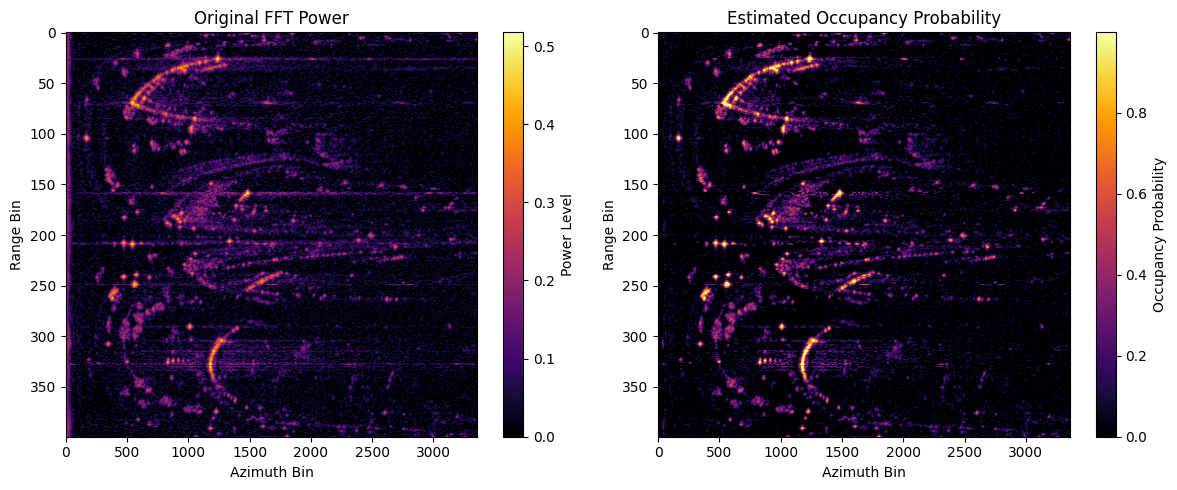

In [36]:
# obtain occ supverison for radar frames
def range_to_world(ranges, bin_length):
    '''
    ## Convert range bin indices into world coords
    ### (radial distances in meters)
    '''
    return ranges * bin_length - (bin_length/2.0)

def compute_occupancy_component(fft_img, occupancy_threshold, highlights_threshold, min_range_bin, binarize=True):
    '''
    ## Thresholds all range-azimuth bins with intensity above occupancy_threshold,\
    and clips all intensities to a max. value of highlights_threshold.
    ## If binarize=True, casts all non-zero bins to 1.0

    NOTE: first min_range_bin range bins are ignored, since these catch the vehicle's
    roof
    '''
    fft = fft_img.clone()
    fft[:,:min_range_bin] = 0.0
    occupied = fft > occupancy_threshold
    occupancy_component = fft * occupied
    occupancy_component = torch.clip(occupancy_component, max=highlights_threshold)

    # Converting to binary mask
    if binarize:
        has_signal = occupancy_component > 0.01
        occupancy_component[has_signal] = 1.0

    return occupancy_component

def update_probability(current_prob, evidence_prob):
    """Bayesian update"""
    return (evidence_prob * current_prob) / ((evidence_prob * current_prob) + (1 - evidence_prob) * (1 - current_prob))

def bayesian_polar_occupancy_map(thresholded_fft, bin_ranges, i_offset=-0.15, i_exp=2.0, decay_bins=10):
    """
    ## Compute a radially-integrated occupancy probability map using a bayesian updated rule

    intensity -> occupancy probability mapping:
    prob. of occupancy = FFT_intensity * e^(i_exp * (FFT_intensity - i_offset))

    integrated probability decay:
    decay factor = e^(-1 * (range_bin_number * num_bins_since_previous_peak) / decay_bins)

    :param thresholded_fft (torch.Tensor): thresholded FFT measurement
    :param bin_ranges (tuple): [min_bin, max_bin], inclusive & 1-indexed
    :param i_offset (float): additive offset to intensity -> occupancy probability mapping
    :param i_exp (float): multiplicative scaler to intensity -> occupancy probability mapping
    :param decay_bins (float/int): decay rate of accumulated radial occupancy probability (in bins)
    :return occ_map (torch.Tensor): occupancy map
    :return integral_map (torch.Tensor): integrated occupancy map
    """
    num_azims = thresholded_fft.shape[0]
    min_bin, max_bin = bin_ranges
    occ_map = torch.full_like(thresholded_fft, 0.5)
    integral_map = torch.full_like(thresholded_fft, 0.5)
    integral_probs = torch.zeros((num_azims)) # [400]
    idx_object_start = (min_bin-1)*torch.ones((num_azims)) # [400]

    for bin_num in torch.arange(min_bin-1, max_bin):
        intensities = thresholded_fft[:, bin_num] # [400]
        exp_decay = np.exp(-(bin_num - idx_object_start) / decay_bins) # decay factor
        integral_probs = exp_decay*integral_probs
        intensity_probs = np.clip(intensities*np.exp(i_exp*(intensities-i_offset)), 0.0, 0.999) # [400]
        idx = integral_probs<intensity_probs
        idx_object_start[idx] = bin_num # Tracking num. bins since previous relative max.
        integral_probs = np.maximum(integral_probs, intensity_probs) # [400]       

        occ_map[:, bin_num] = update_probability(occ_map[:, bin_num], integral_probs)
        integral_map[:, bin_num] = integral_probs

    return occ_map, integral_map

def compute_spherical_grid_noise_threshold(fft_img, min_range, max_range):
    '''
    ## Dynamically threshold all range-azimuth bins with a grid\
    of range-wise and azimuth-wise medians
    '''
    fft = fft_img.clone()

    # Compute per-bin threshold grid
    medians_range, _ = torch.median(fft[:, min_range:max_range+1], axis=1) # [400]
    medians_azimuth, _ = torch.median(fft,axis=0)
    grid = torch.maximum(medians_azimuth.unsqueeze(0), medians_range.unsqueeze(1))
    has_signal = fft > 1.5*grid # [400, 7536]

    return fft * has_signal

def adaptive_gaussian_kernel(ranges, base_sigma=0.044, scaling_factor=0.01, kernel_size=21, bin_size=0.044):
    """
    ## Generate a Gaussian kernel array where sigma increases with radius

    :param ranges (tensor): tensor of ranges, in meters
    :param base_sigma (float): Base value of sigma
    :param scaling_factor (float): Factor by which sigma increases with radius
    :param kernel_size (int): Must be odd
    :param bin_size (float): radial length of bin (meters)
    :return ndarray: Gaussian kernels with radially-varying sigma
    """
    if kernel_size % 2 == 0: kernel_size = kernel_size + 1

    # Radial offsets relative to center of each kernel
    offset = torch.arange(-kernel_size//2+1,kernel_size//2+1)*bin_size # [K=kernel_size]
    sigma = base_sigma + scaling_factor * ranges # [R]

    # Return normalized gaussians
    gaussian = torch.exp(-0.5 * ((offset.unsqueeze(0))/ sigma.unsqueeze(1)) ** 2) # [R, K]
    normalization = torch.sum(gaussian,axis=1).unsqueeze(1) # [R, 1]
    return gaussian / normalization # [R, K]

def adaptive_gaussian_kernel_phi(sigma=2, kernel_size=21):
    """
    ## Generate a Gaussian kernel array for blurring along azimuth

    NOTE: sigma is not adaptive to radial distance, as azimuthal cross-talk
    is fixed and therefore range-invariant

    :param sigma (float): Base value of sigma
    :param kernel_size (int): Must be odd
    :return ndarray: Gaussian kernel with varying sigma
    """
    # Azimuthal offsets relative to center of each kernel
    offset = torch.arange(-kernel_size//2+1,kernel_size//2+1)

    gaussian = torch.exp(-0.5 * ((offset)/ torch.tensor(sigma)) ** 2)
    normalization = torch.sum(gaussian)
    return gaussian / normalization

def apply_radial_deblur_richardson(image, base_sigma=0.088, base_sigma_phi=0.8, scaling_factor=0.044, iterations=5,
                                   filter_epsilon=0.001, max_range_bin=7536, bin_size=0.044, clip=True):
    """
    ## Apply an adaptive radial deblur to an image in polar coordinates

    :param image (ndarray): Image in polar coordinates (radial distance, angle)
    :param base_sigma (float): Base sigma for radial Gaussian kernel
    :param base_sigma_phi (float): Base sigma for azimuthal Gaussian kernel
    :param scaling_factor (float): Scaling factor for sigma based on radius
    :param iterations (int): number of deblurring iterations
    :param filter_epsislon (float): threshold for blurred img to prevent noise amplification
    :param max_range_bin (int): number of range bins in radar
    :param bin_size (float): range bin size (in meters)
    :return ndarray: Deblurred image
    """
    im_deconv = torch.full(image.shape, 0.5)
    unfolded_deconv = torch.Tensor.unfold(torch.nn.functional.pad(im_deconv,(10,10), mode="reflect"), 1, 21, 1)
    radius = range_to_world(torch.arange(max_range_bin)+1, bin_size)  # all bin ranges, in meters
    kernel = adaptive_gaussian_kernel(radius, base_sigma, scaling_factor) # range blur kernel
    kernel_phi = adaptive_gaussian_kernel_phi(sigma=base_sigma_phi).type(torch.float32) # azimuth blur kernel

    for _ in range(iterations):

        conv = torch.sum(unfolded_deconv*kernel.unsqueeze(0), axis=-1)
        conv = torch.nn.functional.conv1d(torch.transpose(conv,0,1).unsqueeze(1),kernel_phi.unsqueeze(0).unsqueeze(0),padding=10).squeeze().transpose(0,1)
        
        if filter_epsilon: relative_blur = torch.where(conv < filter_epsilon, 0, image / conv)
        else: relative_blur = image / conv
        
        unfolded_relative_blur = torch.Tensor.unfold(torch.nn.functional.pad(relative_blur,(10,10), mode="reflect"), 1, 21, 1)
        im_deconv *= torch.sum(unfolded_relative_blur*kernel.unsqueeze(0), axis=-1)
        unfolded_deconv = torch.Tensor.unfold(torch.nn.functional.pad(im_deconv,(10,10), mode="reflect"), 1, 21, 1)
    
    if clip: im_deconv = torch.clip(im_deconv, 0.0, 1.0)
    return im_deconv

def read_json(data_path):
    # Load preprocess JSON

    with open(data_path) as f:
        print(f"Loading in data from:", data_path)
        preprocess = json.load(f)
    
    num_data = len(preprocess['frames'])

    # load poses and radar RA map data
    imgs = []
    timestamps = []
    for i in tqdm(range(num_data), desc=f"Loading radar poses"):
        frame_pth = preprocess['frames'][i]['radar_path']
        img = cv2.imread(frame_pth,cv2.IMREAD_GRAYSCALE)
        img = img[:,11:].astype(np.float32) / 255
        imgs.append(img)
        # obtain timestamp from filename
        timestamp = int(os.path.basename(frame_pth).split('.')[0])
        timestamps.append(timestamp)

    
    return imgs, timestamps

def visualize_fft_and_occupancy(P_r, O_final):
    """
    Plots the original FFT power matrix alongside the computed occupancy probability map.
    
    Parameters:
        P_r (numpy.ndarray): Raw FFT power matrix (num_range_bins x num_azimuth_bins)
        O_final (numpy.ndarray): Final occupancy probability matrix (same shape as P_r)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Original FFT Power Matrix
    im1 = axes[0].imshow(P_r, cmap='inferno', aspect='auto')
    axes[0].set_title("Original FFT Power")
    axes[0].set_xlabel("Azimuth Bin")
    axes[0].set_ylabel("Range Bin")
    plt.colorbar(im1, ax=axes[0], label="Power Level")

    # Plot Computed Occupancy Map
    im2 = axes[1].imshow(O_final, cmap='inferno', aspect='auto')
    axes[1].set_title("Estimated Occupancy Probability")
    axes[1].set_xlabel("Azimuth Bin")
    axes[1].set_ylabel("Range Bin")
    plt.colorbar(im2, ax=axes[1], label="Occupancy Probability")

    # Show the plots
    plt.tight_layout()
    plt.show()


imgs,timestamps = read_json(data_json_path)
imgs[1].shape
save_folder = os.path.join(project_folder,sequence,'occ')
min_range = 0
max_range = 3360
if not os.path.exists(save_folder):
        os.makedirs(save_folder)
occs = []

for i in tqdm(range(len(imgs))):
        save_path = os.path.join(save_folder, str(timestamps[i]) + '.npy')
        if os.path.exists(save_path):
            # skip if already exists
            continue
        img = torch.from_numpy(imgs[i]).float()
        thresholded_fft = compute_spherical_grid_noise_threshold(img, min_range, max_range)
        occ, _ = bayesian_polar_occupancy_map(thresholded_fft, bin_ranges=(min_range, max_range))
        # Save occ in the folder#
        np.save(save_path, occ)
        occs.append(occ)
occs = np.stack(occs, axis=0)

index = 7
visualize_fft_and_occupancy(imgs[index],occs[index])